In [1]:
# 📌 Step 1: Import library
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, ConstantKernel as C, WhiteKernel
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load dataset
df = pd.read_csv("Merged (Gas per jam).csv")

# Kolom yang dibutuhkan
selected_columns = ['GAS_MMBTU','D101330TT (Tem.outlet chamber)','D102265TIC_PV (Temp. inlet chamber)','D102260TIC_CV (High press. Steam damper)','D102265TIC_CV (Low press. Steam damper)','D102266TIC (Main heater dehumidifier)']
df_clean = df[selected_columns].dropna()

# Ambil sampel data untuk efisiensi GPR
df_sample = df_clean.sample(n=500, random_state=42)


In [3]:
X = df_sample[['GAS_MMBTU']].values
target_columns = selected_columns[1:]  # 5 kolom target output dryer

In [7]:
kernel = C(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=1.0, alpha=1.0) + WhiteKernel()

In [8]:
# 📌 Step 5: Train, simpan model, dan evaluasi
results = []

# Train ulang & simpan model baru
for col in target_columns:
    y = df_sample[col].values
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=2)
    gpr.fit(X_train, y_train)

    # ✅ Fix: Hilangkan generator random
    gpr.random_state = None

    # Simpan ulang model bersih
    joblib.dump(gpr, f"model_{col}.pkl")
    print(f"✅ Model {col} berhasil disimpan.")

    # Evaluasi model
    y_pred = gpr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Parameter': col,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })


C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


✅ Model D101330TT (Tem.outlet chamber) berhasil disimpan.


C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


✅ Model D102265TIC_PV (Temp. inlet chamber) berhasil disimpan.


C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


✅ Model D102260TIC_CV (High press. Steam damper) berhasil disimpan.
✅ Model D102265TIC_CV (Low press. Steam damper) berhasil disimpan.
✅ Model D102266TIC (Main heater dehumidifier) berhasil disimpan.


In [9]:
# 📌 Step 6: Tampilkan hasil evaluasi
results_df = pd.DataFrame(results)
results_df

,Parameter,MSE,RMSE,R2 Score
0,D101330TT (Tem.outlet chamber),89.379273,9.454061,0.891913
1,D102265TIC_PV (Temp. inlet chamber),5082.779131,71.293612,-0.001484
2,D102260TIC_CV (High press. Steam damper),186.990409,13.674444,0.774540
3,D102265TIC_CV (Low press. Steam damper),183.546765,13.547943,0.467139
4,D102266TIC (Main heater dehumidifier),6.144217,2.478753,0.863044


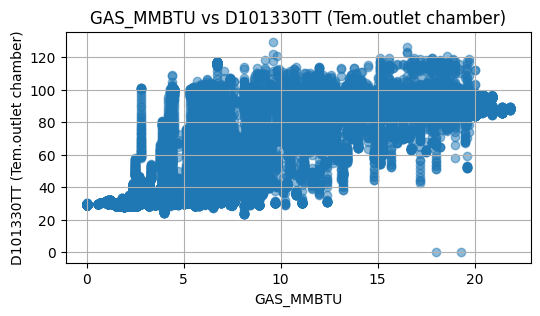

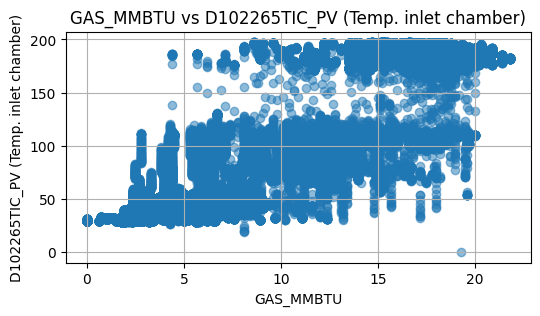

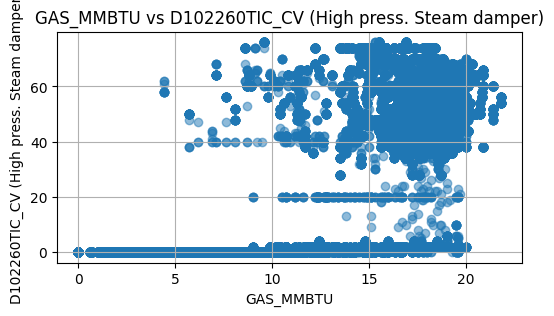

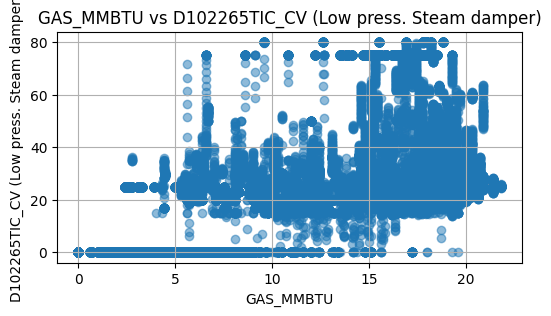

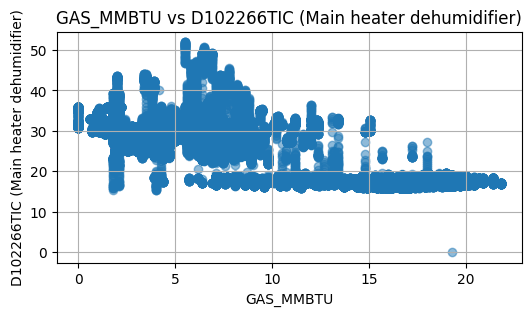

In [10]:
import matplotlib.pyplot as plt

for col in target_columns:
    plt.figure(figsize=(6, 3))
    plt.scatter(df['GAS_MMBTU'], df[col], alpha=0.5)
    plt.title(f"GAS_MMBTU vs {col}")
    plt.xlabel("GAS_MMBTU")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

In [11]:
df[['GAS_MMBTU'] + target_columns].corr()

,GAS_MMBTU,D101330TT (Tem.outlet chamber),D102265TIC_PV (Temp. inlet chamber),D102260TIC_CV (High press. Steam damper),D102265TIC_CV (Low press. Steam damper),D102266TIC (Main heater dehumidifier)
GAS_MMBTU,1.000000,0.936848,0.948947,0.872834,0.698175,-0.889447
D101330TT (Tem.outlet chamber),0.936848,1.000000,0.941569,0.814512,0.716229,-0.874221
D102265TIC_PV (Temp. inlet chamber),0.948947,0.941569,1.000000,0.946014,0.754027,-0.882827
D102260TIC_CV (High press. Steam damper),0.872834,0.814512,0.946014,1.000000,0.760654,-0.814287
D102265TIC_CV (Low press. Steam damper),0.698175,0.716229,0.754027,0.760654,1.000000,-0.704266
D102266TIC (Main heater dehumidifier),-0.889447,-0.874221,-0.882827,-0.814287,-0.704266,1.000000


In [12]:
import pandas as pd
import numpy as np
import joblib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RationalQuadratic, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("Merged (Gas per jam).csv")

# Kolom yang dibutuhkan
selected_columns = [
    'GAS_MMBTU',
    'D101330TT (Tem.outlet chamber)',
    'D102265TIC_PV (Temp. inlet chamber)',
    'D102260TIC_CV (High press. Steam damper)',
    'D102265TIC_CV (Low press. Steam damper)',
    'D102266TIC (Main heater dehumidifier)'
]

# Bersihkan data
df_clean = df[selected_columns].dropna()

# Ambil 1000 data acak agar GPR tidak terlalu berat tapi tetap cukup representatif
df_sample = df_clean.sample(n=1000, random_state=42)

# Input dan target
X = df_sample[['GAS_MMBTU']].values
target_columns = selected_columns[1:]  # 5 kolom target dryer

# Kernel yang lebih fleksibel
kernel = (
    C(1.0, (1e-2, 1e2)) * RationalQuadratic(length_scale=2.0, alpha=0.5)
    + WhiteKernel(noise_level=1, noise_level_bounds=(1e-5, 1e1))
)

results = []

# Loop tiap target kolom
for col in target_columns:
    y = df_sample[col].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    gpr = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,  # lebih banyak restart untuk cari kernel terbaik
        alpha=0.01  # tambahkan regularisasi
    )
    gpr.fit(X_train, y_train)

    # Simpan model
    model_name = col.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "")
    joblib.dump(gpr, f"gpr_model_{model_name}.pkl")

    # Evaluasi
    y_pred = gpr.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mean_actual = np.mean(y_test)
    mean_pred = np.mean(y_pred)
    accuracy_vs_mean = 100 - abs(mean_pred - mean_actual) / mean_actual * 100

    results.append({
        "Parameter": col,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "Mean_Actual": round(mean_actual, 2),
        "Mean_Predicted": round(mean_pred, 2),
        "Accuracy_vs_Mean (%)": round(accuracy_vs_mean, 2)
    })

# Tampilkan hasil evaluasi
results_df = pd.DataFrame(results)
print(results_df)


C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarni

                                  Parameter       MSE     RMSE      R2  \
0            D101330TT (Tem.outlet chamber)   87.4725   9.3527  0.8981   
1       D102265TIC_PV (Temp. inlet chamber)  461.4676  21.4818  0.9068   
2  D102260TIC_CV (High press. Steam damper)  160.8770  12.6837  0.7823   
3   D102265TIC_CV (Low press. Steam damper)  142.6123  11.9420  0.4455   
4     D102266TIC (Main heater dehumidifier)    6.0639   2.4625  0.8549   

   Mean_Actual  Mean_Predicted  Accuracy_vs_Mean (%)  
0        66.44           66.74                 99.55  
1       110.18          113.60                 96.90  
2        24.54           27.07                 89.67  
3        15.79           17.19                 91.16  
4        22.99           23.13                 99.40  


C:\Users\cinta\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
